> **Setup notebook — not part of `scripts/run_phase1.py`.**
> Runs once to produce `backend/data/boundaries/psgc_provinces.geojson`
> and `visayas_islands.geojson`, which the Phase 1 pipeline reads as
> upstream inputs. Re-run only if GADM updates or the province ↔
> island mapping changes.

# Day 2 — Boundary Preparation

Build `psgc_provinces.geojson` (16 Visayas provinces with PSGC codes + island tag) and `visayas_islands.geojson` (9 dissolved island polygons) from GADM 4.1.

**Important:** GADM 4.1 PH uses a flat hierarchy: `ADM_ADM_1` = province, `ADM_ADM_2` = municipality. There is no region layer. We use the PSGC reference CSV as both the Visayas filter and the official code source.

Inputs: `backend/data/boundaries/gadm41_PHL.gpkg`, `backend/data/boundaries/psgc_provinces_reference.csv`.

Outputs: `backend/data/boundaries/psgc_provinces.geojson`, `backend/data/boundaries/visayas_islands.geojson`.

In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

BOUND_DIR = Path('../backend/data/boundaries')
assert BOUND_DIR.exists(), BOUND_DIR

## Step 2.1 — Load GADM provinces (ADM_ADM_1)

In [2]:
adm1 = gpd.read_file(BOUND_DIR / 'gadm41_PHL.gpkg', layer='ADM_ADM_1')
print('PH provinces in GADM:', len(adm1))
adm1[['NAME_1', 'TYPE_1', 'ENGTYPE_1']].head(3)

PH provinces in GADM: 81


,NAME_1,TYPE_1,ENGTYPE_1
0,Abra,Lalawigan,Province
1,Agusan del Norte,Lalawigan,Province
2,Agusan del Sur,Lalawigan,Province


## Step 2.2 — Filter to Visayas via PSGC reference (16 provinces)

The PSGC CSV is the authoritative list of Visayas provinces. Inner-merge GADM provinces against it: any GADM row not matched is non-Visayas, any PSGC row not matched is a name divergence we need to alias.

In [3]:
psgc_ref = pd.read_csv(BOUND_DIR / 'psgc_provinces_reference.csv', dtype={'psgc_code': str})
print('PSGC ref rows:', len(psgc_ref))

# Alias table for any GADM ≠ PSA naming. Extend if mismatches surface below.
GADM_TO_PSA = {
    # 'Davao de Oro': 'Compostela Valley',  # example pattern
}
adm1['psa_name'] = adm1['NAME_1'].replace(GADM_TO_PSA)

visayas = adm1.merge(psgc_ref, left_on='psa_name', right_on='province_name', how='inner')
print('Matched Visayas provinces:', len(visayas))
print(sorted(visayas['psa_name'].tolist()))

missing_from_gadm = set(psgc_ref['province_name']) - set(visayas['psa_name'])
print('PSGC entries not matched in GADM:', missing_from_gadm)
assert len(visayas) == 16, f'Expected 16 Visayas provinces, got {len(visayas)}'
assert not missing_from_gadm, f'Need alias entries for: {missing_from_gadm}'

PSGC ref rows: 16
Matched Visayas provinces: 16
['Aklan', 'Antique', 'Biliran', 'Bohol', 'Capiz', 'Cebu', 'Eastern Samar', 'Guimaras', 'Iloilo', 'Leyte', 'Negros Occidental', 'Negros Oriental', 'Northern Samar', 'Samar', 'Siquijor', 'Southern Leyte']
PSGC entries not matched in GADM: set()


## Step 2.3 — Province → island mapping (9 islands)

Each entry below is a physical landmass with its own (or sub-isolated) grid. Guimaras, Siquijor, and Biliran stay separate because they are submarine-fed and matter for Phase 1C synthesis.

In [4]:
PROVINCE_TO_ISLAND = {
    # Panay
    'Aklan': 'Panay', 'Antique': 'Panay', 'Capiz': 'Panay', 'Iloilo': 'Panay',
    'Guimaras': 'Guimaras',
    # Negros
    'Negros Occidental': 'Negros', 'Negros Oriental': 'Negros',
    # Central
    'Cebu': 'Cebu', 'Bohol': 'Bohol', 'Siquijor': 'Siquijor',
    # Leyte / Samar group
    'Leyte': 'Leyte', 'Southern Leyte': 'Leyte',
    'Biliran': 'Biliran',
    'Samar': 'Samar', 'Eastern Samar': 'Samar', 'Northern Samar': 'Samar',
}
visayas['island_name'] = visayas['psa_name'].map(PROVINCE_TO_ISLAND)
assert visayas['island_name'].notna().all(), \
    'Unmapped: ' + str(visayas[visayas['island_name'].isna()]['psa_name'].tolist())
visayas[['psa_name', 'island_name', 'psgc_code']].sort_values(['island_name', 'psa_name'])

,psa_name,island_name,psgc_code
2,Biliran,Biliran,0878000000
3,Bohol,Bohol,0712000000
5,Cebu,Cebu,0722000000
7,Guimaras,Guimaras,0679000000
9,Leyte,Leyte,0837000000
15,Southern Leyte,Leyte,0864000000
10,Negros Occidental,Negros,0645000000
11,Negros Oriental,Negros,0746000000
0,Aklan,Panay,0604000000
1,Antique,Panay,0606000000


## Step 2.4 — Dissolve to island polygons

In [5]:
islands = (
    visayas[['psa_name', 'island_name', 'geometry']]
    .dissolve(by='island_name', aggfunc={'psa_name': list})
    .rename(columns={'psa_name': 'provinces'})
    .reset_index()
)
print('Islands:', len(islands))
print(islands[['island_name', 'provinces']].to_string(index=False))
assert len(islands) == 9, f'Expected 9 islands, got {len(islands)}'

Islands: 9
island_name                              provinces
    Biliran                              [Biliran]
      Bohol                                [Bohol]
       Cebu                                 [Cebu]
   Guimaras                             [Guimaras]
      Leyte                [Leyte, Southern Leyte]
     Negros   [Negros Occidental, Negros Oriental]
      Panay        [Aklan, Antique, Capiz, Iloilo]
      Samar [Eastern Samar, Northern Samar, Samar]
   Siquijor                             [Siquijor]


## Step 2.5 — Validate (geometry + area sanity)

In [6]:
assert visayas.geometry.is_valid.all(), 'Invalid province geometry'
assert islands.geometry.is_valid.all(), 'Invalid island geometry'

islands_m = islands.to_crs(32651)  # UTM 51N for Visayas
islands_m['area_km2'] = islands_m.geometry.area / 1e6

EXPECTED_KM2 = {
    'Panay': 12300, 'Negros': 13300, 'Cebu': 4950, 'Leyte': 7370,
    'Samar': 13400, 'Bohol': 4820, 'Guimaras': 605, 'Biliran': 555, 'Siquijor': 343,
}
report = islands_m[['island_name', 'area_km2']].copy()
report['expected_km2'] = report['island_name'].map(EXPECTED_KM2)
report['pct_diff'] = (report['area_km2'] - report['expected_km2']) / report['expected_km2'] * 100
print(report.to_string(index=False))

TOLERANCE_PCT = 10  # GADM admin boundaries don't trace coastlines perfectly
outliers = report[report['pct_diff'].abs() > TOLERANCE_PCT]
if len(outliers):
    print(f'\nWARNING: {len(outliers)} islands outside ±{TOLERANCE_PCT}% tolerance:')
    print(outliers.to_string(index=False))

island_name     area_km2  expected_km2   pct_diff
    Biliran   534.328717           555  -3.724556
      Bohol  3976.874410          4820 -17.492232
       Cebu  4878.700279          4950  -1.440398
   Guimaras   604.531310           605  -0.077470
      Leyte  7246.727927          7370  -1.672620
     Negros 12800.333379         13300  -3.756892
      Panay 11757.252993         12300  -4.412577
      Samar 13120.965746         13400  -2.082345
   Siquijor   320.719798           343  -6.495686

island_name   area_km2  expected_km2   pct_diff
      Bohol 3976.87441          4820 -17.492232


Text(85.32657164380511, 0.5, 'Latitude')

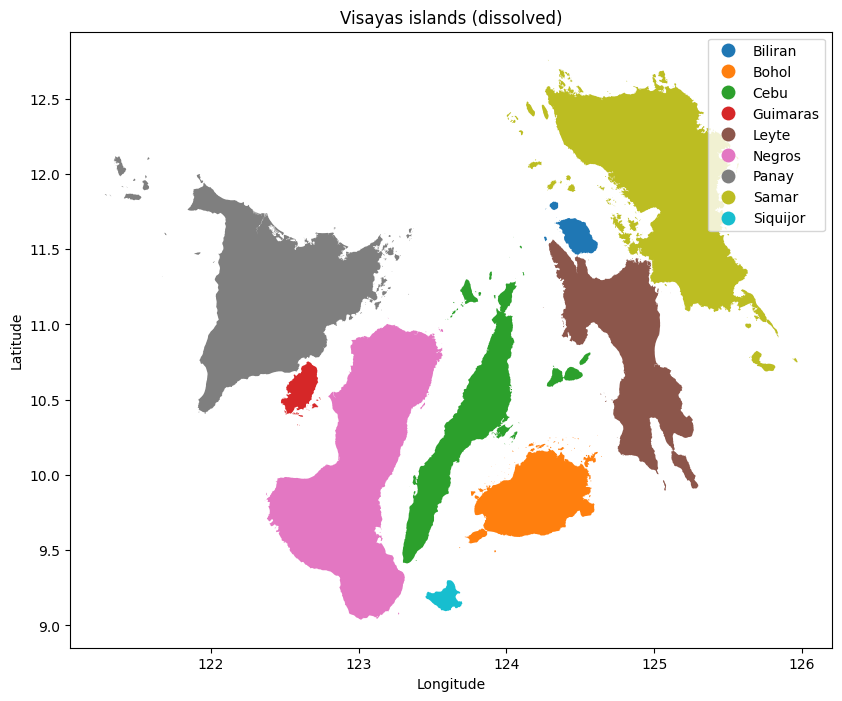

In [7]:
ax = islands.plot(column='island_name', legend=True, figsize=(10, 8), cmap='tab10')
ax.set_title('Visayas islands (dissolved)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

## Step 2.6 — Save

In [8]:
provinces_out = visayas.rename(columns={'psa_name': 'province'})[
    ['psgc_code', 'province', 'region', 'island_name', 'geometry']
]
provinces_out.to_file(BOUND_DIR / 'psgc_provinces.geojson', driver='GeoJSON')

# GeoJSON does not natively support list-valued columns — stringify
islands_out = islands.copy()
islands_out['provinces'] = islands_out['provinces'].apply(lambda xs: ','.join(sorted(xs)))
islands_out.to_file(BOUND_DIR / 'visayas_islands.geojson', driver='GeoJSON')

print('Wrote:')
print(' ', BOUND_DIR / 'psgc_provinces.geojson')
print(' ', BOUND_DIR / 'visayas_islands.geojson')

Wrote:
  ../backend/data/boundaries/psgc_provinces.geojson
  ../backend/data/boundaries/visayas_islands.geojson
